# Task VII: Equivariant Quantum Neural Networks


**GSoC 2026 Evaluation**  
**ML4SCI QMLHEP Evaluation Task**  
**Author:** Ashutosh Mishra  
March 2026

---

This notebook implements and compares **non-equivariant** and **Z₂ × Z₂ equivariant** quantum neural networks for a symmetric 2D classification problem.

**References:**
- [Nguyen et al., arXiv:2205.06217](https://arxiv.org/abs/2205.06217) — Theory for Z₂ × Z₂ equivariant QNNs
- [Meyer et al., arXiv:2210.08566](https://arxiv.org/abs/2210.08566) — Exploiting symmetry in variational quantum machine learning

**Key idea:** When the classification task has a known symmetry group, I can build quantum circuits whose gates commute with the group action. This "bakes in" the symmetry, reducing the effective parameter space and improving sample/parameter efficiency.

In [1]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
pnp.random.seed(42)

print(f"PennyLane version: {qml.__version__}")

PennyLane version: 0.44.1


---
## 1. Dataset Generation — Z₂ × Z₂ Symmetric Classification

The group **Z₂ × Z₂** acts on ℝ² by independently flipping the sign of each coordinate:

$$G = \{(x_1, x_2),\; (-x_1, x_2),\; (x_1, -x_2),\; (-x_1, -x_2)\}$$

A classifier $f$ is **invariant** under this group iff $f(g \cdot \mathbf{x}) = f(\mathbf{x})$ for all $g \in G$.

I choose the decision boundary $|x_1| + |x_2| = r$ (a diamond / L1 ball), which is manifestly Z₂ × Z₂ invariant:
- **Class 0** (inside diamond): $|x_1| + |x_2| < r$
- **Class 1** (outside diamond): $|x_1| + |x_2| > r$

In [2]:
def generate_z2z2_dataset(n_per_class=500, threshold=1.0, spread=1.8, seed=42):
    """Generate a 2D dataset with Z2xZ2 symmetric decision boundary."""
    rng = np.random.RandomState(seed)
    
    X_class0, X_class1 = [], []
    
    # Class 0: inside diamond |x1| + |x2| < threshold
    while len(X_class0) < n_per_class:
        pts = rng.uniform(-spread, spread, size=(n_per_class * 4, 2))
        mask = np.abs(pts[:, 0]) + np.abs(pts[:, 1]) < threshold
        X_class0.extend(pts[mask])
    X_class0 = np.array(X_class0[:n_per_class])
    
    # Class 1: outside diamond |x1| + |x2| > threshold (with upper bound)
    while len(X_class1) < n_per_class:
        pts = rng.uniform(-spread, spread, size=(n_per_class * 4, 2))
        l1 = np.abs(pts[:, 0]) + np.abs(pts[:, 1])
        mask = (l1 > threshold) & (l1 < spread)
        X_class1.extend(pts[mask])
    X_class1 = np.array(X_class1[:n_per_class])
    
    X = np.vstack([X_class0, X_class1])
    y = np.array([0]*n_per_class + [1]*n_per_class)
    
    # Shuffle
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

X, y = generate_z2z2_dataset()
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Class distribution: {np.bincount(y)}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(y_train)}, Test: {len(y_test)}")

Dataset: 1000 samples, 2 features
Class distribution: [500 500]
Train: 800, Test: 200


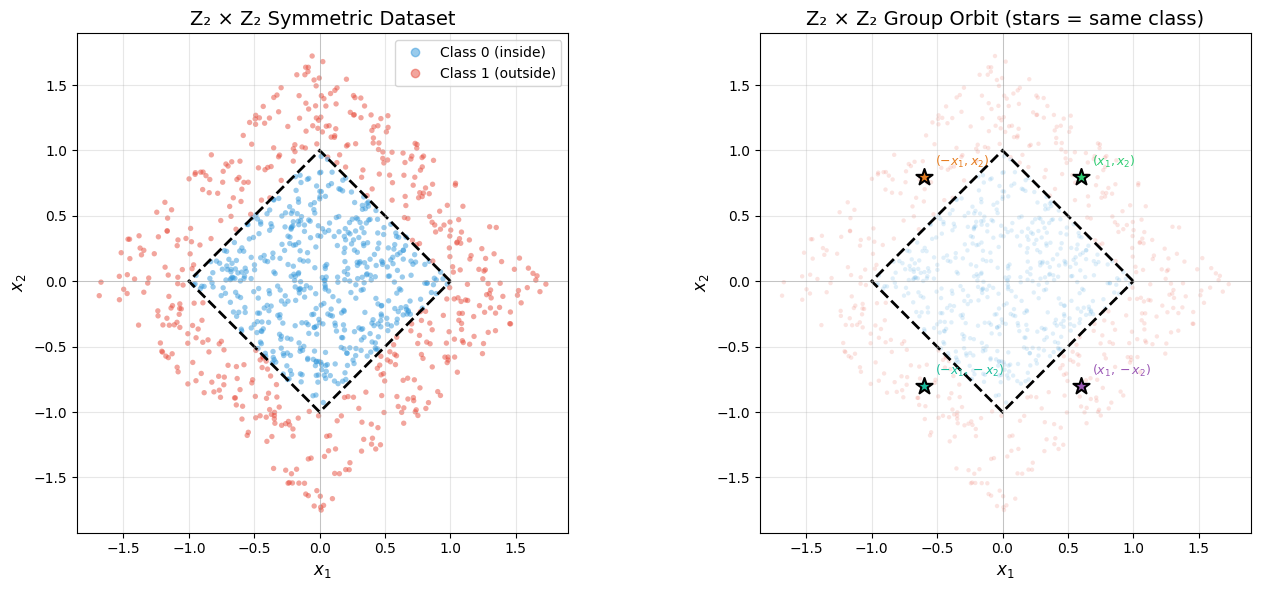

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot dataset
ax = axes[0]
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#3498db', '#e74c3c']),
                     alpha=0.5, s=15, edgecolors='none')
# Draw diamond boundary
diamond = plt.Polygon([(1,0), (0,1), (-1,0), (0,-1)], fill=False,
                       edgecolor='black', linewidth=2, linestyle='--')
ax.add_patch(diamond)
ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Z₂ × Z₂ Symmetric Dataset', fontsize=14)
ax.legend(handles=scatter.legend_elements()[0], labels=['Class 0 (inside)', 'Class 1 (outside)'])
ax.set_aspect('equal')
ax.axhline(y=0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5, alpha=0.5)
ax.grid(True, alpha=0.3)

# Show symmetry: plot a point and its 4 group images
ax = axes[1]
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#3498db', '#e74c3c']),
           alpha=0.15, s=10, edgecolors='none')
diamond2 = plt.Polygon([(1,0), (0,1), (-1,0), (0,-1)], fill=False,
                        edgecolor='black', linewidth=2, linestyle='--')
ax.add_patch(diamond2)

# Highlight Z2xZ2 orbit of a sample point
p = np.array([0.6, 0.8])
orbit = np.array([[p[0], p[1]], [-p[0], p[1]], [p[0], -p[1]], [-p[0], -p[1]]])
colors_orbit = ['#2ecc71', '#e67e22', '#9b59b6', '#1abc9c']
labels_orbit = ['$(x_1, x_2)$', '$(-x_1, x_2)$', '$(x_1, -x_2)$', '$(-x_1, -x_2)$']
for i, (pt, c, lab) in enumerate(zip(orbit, colors_orbit, labels_orbit)):
    ax.scatter(*pt, c=c, s=150, zorder=5, edgecolors='black', linewidth=1.5, marker='*')
    ax.annotate(lab, pt, textcoords='offset points', xytext=(8, 8), fontsize=9, color=c, fontweight='bold')

ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Z₂ × Z₂ Group Orbit (stars = same class)', fontsize=14)
ax.set_aspect('equal')
ax.axhline(y=0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5, alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2. Non-Equivariant QNN (Baseline)

A standard variational quantum classifier that makes **no attempt** to respect the Z₂ × Z₂ symmetry. This serves as our baseline to measure the effect of building in equivariance.

**Circuit design:**
- **Encoding:** $R_X(x_1)$ on qubit 0, $R_X(x_2)$ on qubit 1 (single-shot, not re-uploaded)
- **Ansatz (per layer):** $R_Y(\theta) \otimes R_Y(\phi)$, then $R_Z(\alpha) \otimes R_Z(\beta)$, then CNOT
- **Measurement:** $\langle Z_0 \rangle$
- 3 layers, 4 parameters each → 12 trainable parameters total

In [4]:
n_qubits = 2
n_layers_noneq = 3

dev_noneq = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev_noneq, interface='autograd')
def non_equivariant_qnn(x, params):
    """Non-equivariant variational quantum classifier."""
    # Feature encoding
    qml.RX(x[0], wires=0)
    qml.RX(x[1], wires=1)
    
    # Variational layers
    for l in range(n_layers_noneq):
        qml.RY(params[l, 0], wires=0)
        qml.RY(params[l, 1], wires=1)
        qml.RZ(params[l, 2], wires=0)
        qml.RZ(params[l, 3], wires=1)
        qml.CNOT(wires=[0, 1])
    
    return qml.expval(qml.PauliZ(0))

# Draw circuit
x_sample = pnp.array([0.5, 0.3])
params_sample = pnp.zeros((n_layers_noneq, 4))
print("Non-equivariant QNN circuit:")
print(qml.draw(non_equivariant_qnn)(x_sample, params_sample))
print(f"\nTrainable parameters: {n_layers_noneq * 4} = {n_layers_noneq} layers × 4 params/layer")

Non-equivariant QNN circuit:
0: ──RX(0.50)──RY(0.00)──RZ(0.00)─╭●──RY(0.00)──RZ(0.00)─╭●──RY(0.00)──RZ(0.00)─╭●─┤  <Z>
1: ──RX(0.30)──RY(0.00)──RZ(0.00)─╰X──RY(0.00)──RZ(0.00)─╰X──RY(0.00)──RZ(0.00)─╰X─┤     

Trainable parameters: 12 = 3 layers × 4 params/layer


In [5]:
def cost_noneq(params, X_batch, y_batch):
    """MSE cost for non-equivariant QNN (autograd-compatible)."""
    loss = 0.0
    for i in range(len(y_batch)):
        x = X_batch[i]
        label = float(y_batch[i])
        pred = non_equivariant_qnn(x, params)
        # Target: class 0 -> +1, class 1 -> -1
        target = 1.0 - 2.0 * label
        loss = loss + (pred - target) ** 2
    return loss / len(y_batch)

def predict_noneq(params, X_data):
    """Predict labels using non-equivariant QNN."""
    preds = []
    for x in X_data:
        exp_val = float(non_equivariant_qnn(x, params))
        preds.append(1 if exp_val < 0 else 0)
    return np.array(preds)

def accuracy(params, X_data, y_data, predict_fn):
    return np.mean(predict_fn(params, X_data) == np.array(y_data))

In [6]:
# Scale features to [0, pi] for encoding
def scale_features(X, scale=np.pi):
    X_min, X_max = X.min(axis=0), X.max(axis=0)
    return scale * (X - X_min) / (X_max - X_min)

X_train_s = pnp.array(scale_features(X_train), requires_grad=False)
X_test_s = pnp.array(scale_features(X_test), requires_grad=False)
# Keep labels as plain numpy arrays to avoid autograd issues
y_train_pnp = np.array(y_train, dtype=float)
y_test_pnp = np.array(y_test, dtype=float)

In [7]:
# Training the non-equivariant QNN
np.random.seed(42)
params_noneq = pnp.array(np.random.uniform(-np.pi, np.pi, (n_layers_noneq, 4)), requires_grad=True)
opt_noneq = qml.AdamOptimizer(stepsize=0.05)

n_epochs = 60
batch_size = 32

history_noneq = {'loss': [], 'train_acc': [], 'test_acc': []}

# Fixed evaluation subset (same points every epoch, for smooth curves)
eval_train_idx = np.random.permutation(len(y_train_pnp))[:100]

print("Training Non-Equivariant QNN...")
for epoch in range(n_epochs):
    idx = np.random.permutation(len(y_train_pnp))[:batch_size]
    X_batch = X_train_s[idx]
    y_batch = y_train_pnp[idx]
    
    params_noneq, loss_val = opt_noneq.step_and_cost(
        lambda p: cost_noneq(p, X_batch, y_batch), params_noneq
    )
    
    history_noneq['loss'].append(float(loss_val))
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        train_acc = accuracy(params_noneq, X_train_s[eval_train_idx],
                             y_train_pnp[eval_train_idx], predict_noneq)
        test_acc = accuracy(params_noneq, X_test_s, y_test_pnp, predict_noneq)
        history_noneq['train_acc'].append(train_acc)
        history_noneq['test_acc'].append(test_acc)
        print(f"  Epoch {epoch+1:3d} | Loss: {float(loss_val):.4f} "
              f"| Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")
    else:
        # Lightweight tracking (small subset)
        tr_acc = accuracy(params_noneq, X_train_s[eval_train_idx[:50]],
                          y_train_pnp[eval_train_idx[:50]], predict_noneq)
        te_acc = accuracy(params_noneq, X_test_s[:50], y_test_pnp[:50], predict_noneq)
        history_noneq['train_acc'].append(tr_acc)
        history_noneq['test_acc'].append(te_acc)

final_test_acc_noneq = accuracy(params_noneq, X_test_s, y_test_pnp, predict_noneq)
print(f"\nFinal Test Accuracy (Non-Equivariant): {final_test_acc_noneq:.4f}")

Training Non-Equivariant QNN...
  Epoch   1 | Loss: 1.0929 | Train Acc: 0.620 | Test Acc: 0.650
  Epoch  10 | Loss: 1.2090 | Train Acc: 0.780 | Test Acc: 0.730
  Epoch  20 | Loss: 0.8560 | Train Acc: 0.680 | Test Acc: 0.720
  Epoch  30 | Loss: 0.7743 | Train Acc: 0.620 | Test Acc: 0.665
  Epoch  40 | Loss: 0.8622 | Train Acc: 0.650 | Test Acc: 0.675
  Epoch  50 | Loss: 0.8809 | Train Acc: 0.720 | Test Acc: 0.685
  Epoch  60 | Loss: 0.8810 | Train Acc: 0.650 | Test Acc: 0.685

Final Test Accuracy (Non-Equivariant): 0.6850


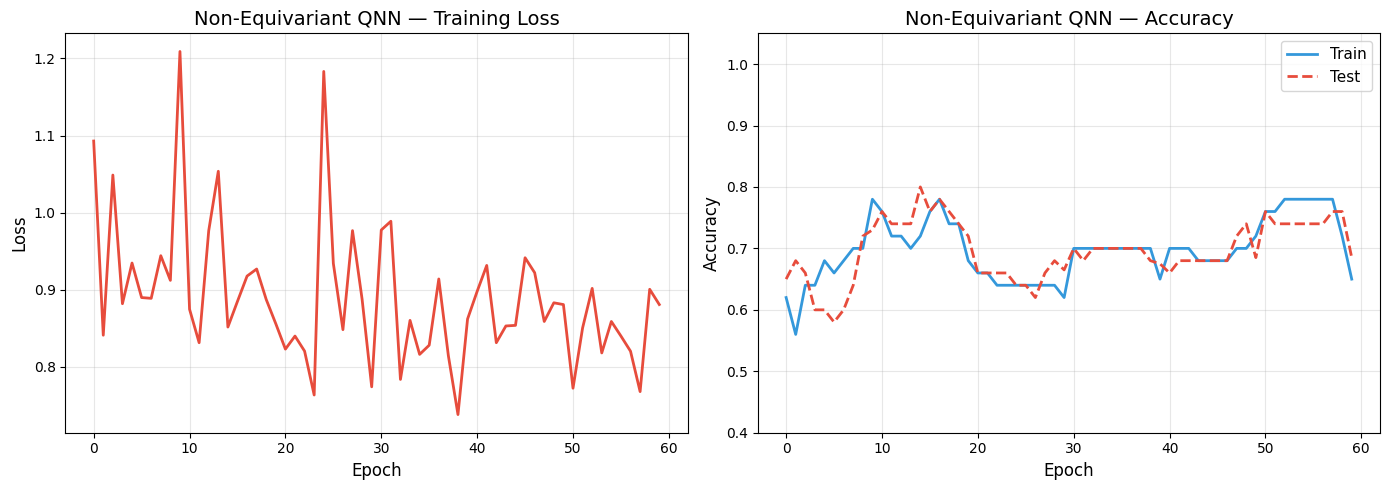

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_noneq['loss'], color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Non-Equivariant QNN — Training Loss', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_noneq['train_acc'], label='Train', color='#3498db', linewidth=2)
axes[1].plot(history_noneq['test_acc'], label='Test', color='#e74c3c', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Non-Equivariant QNN — Accuracy', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.4, 1.05])

plt.tight_layout()
plt.show()

---
## 3. Z₂ × Z₂ Equivariant QNN

Following [arXiv:2205.06217](https://arxiv.org/abs/2205.06217), I construct a variational circuit whose output is guaranteed to be **invariant** under Z₂ × Z₂, regardless of parameter values.

### How the symmetry maps onto qubits

The feature encoding $R_Y(x_1) \otimes R_Y(x_2)$ acting on $|00\rangle$ produces amplitudes that depend on $\cos(x_i/2)$ and $\sin(x_i/2)$. Negating a feature $x_i \to -x_i$ flips the sign of the $\sin$ component on that qubit. Algebraically, this is the same as conjugating by Pauli-$Z$ on that qubit:

$$R_Y(-x_i)|0\rangle = Z_i \, R_Y(x_i) |0\rangle$$

So the Z₂ × Z₂ generators, which flip feature signs, are **represented on the Hilbert space** by $Z_0$ and $Z_1$.

### Equivariance conditions

For the full map $f(\mathbf{x}) = \langle 0 | \, U(\mathbf{x})^\dagger \, O \, U(\mathbf{x}) \, |0\rangle$ to satisfy $f(g \cdot \mathbf{x}) = f(\mathbf{x})$, I need:

1. **Variational gates** must commute with the representation: $[V, Z_i] = 0$. Gates diagonal in the computational basis satisfy this, in particular $R_Z(\theta)$ and $e^{-i\theta Z_0 Z_1}$ (IsingZZ).

2. **Observable** must be invariant under conjugation: $Z_i \, O \, Z_i = O$. The product $Z_0 Z_1$ satisfies this since $Z_i (Z_0 Z_1) Z_i = Z_0 Z_1$ (each $Z_i$ commutes with the product).

### Circuit architecture (per layer)

| Step | Gate | Why equivariant |
|------|------|----------------|
| Encoding | $R_Y(x_1) \otimes R_Y(x_2)$ | Creates superposition; negation ↔ $Z$ conjugation |
| Trainable rotations | $R_Z(\theta_1) \otimes R_Z(\theta_2)$ | Diagonal ⟹ commutes with $Z_0, Z_1$ |
| Entangling | $e^{-i\alpha Z_0 Z_1}$ | Diagonal ⟹ commutes with $Z_0, Z_1$ |

**Measurement:** $\langle Z_0 Z_1 \rangle$ — invariant under $Z_i$ conjugation.

The data re-uploading pattern (encoding repeated every layer) is key: phases accumulated by the diagonal variational gates interfere with the amplitudes created by the next $R_Y$ encoding, producing non-trivial feature dependence while preserving equivariance.

In [9]:
n_layers_eq = 3

dev_eq = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev_eq, interface='autograd')
def equivariant_qnn(x, params):
    """Z2 x Z2 equivariant QNN using data re-uploading.
    
    Per layer:
      1. RY(x1) on q0, RY(x2) on q1   — equivariant encoding
      2. RZ(theta) on q0, q1            — diagonal, commutes with Z
      3. IsingZZ(alpha) on (q0, q1)     — diagonal, commutes with Z
    Measurement: <Z0 Z1> (invariant under Z-conjugation)
    """
    for l in range(n_layers_eq):
        # Equivariant encoding: RY creates superpositions,
        # and RY(-x)|0> = Z * RY(x)|0>, so negating a feature
        # is equivalent to Z-conjugation on that qubit.
        qml.RY(x[0], wires=0)
        qml.RY(x[1], wires=1)
        
        # Trainable rotations (diagonal => commute with Z0, Z1)
        qml.RZ(params[l, 0], wires=0)
        qml.RZ(params[l, 1], wires=1)
        
        # ZZ entangling gate (diagonal => commutes with Z0, Z1)
        qml.IsingZZ(params[l, 2], wires=[0, 1])
    
    # Invariant observable: Z_i (Z0 Z1) Z_i = Z0 Z1
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

params_eq_sample = pnp.zeros((n_layers_eq, 3))
print("Z2 x Z2 Equivariant QNN circuit:")
print(qml.draw(equivariant_qnn)(x_sample, params_eq_sample))
print(f"\nTrainable parameters: {n_layers_eq * 3} = {n_layers_eq} layers x 3 params/layer")

Z2 x Z2 Equivariant QNN circuit:
0: ──RY(0.50)──RZ(0.00)─╭IsingZZ(0.00)──RY(0.50)──RZ(0.00)─╭IsingZZ(0.00)──RY(0.50)──RZ(0.00) ···
1: ──RY(0.30)──RZ(0.00)─╰IsingZZ(0.00)──RY(0.30)──RZ(0.00)─╰IsingZZ(0.00)──RY(0.30)──RZ(0.00) ···

0: ··· ─╭IsingZZ(0.00)─┤ ╭<Z@Z>
1: ··· ─╰IsingZZ(0.00)─┤ ╰<Z@Z>

Trainable parameters: 9 = 3 layers x 3 params/layer


In [10]:
# Verify equivariance numerically: f(x1, x2) should equal f(+-x1, +-x2)
test_params = pnp.array(np.random.uniform(-np.pi, np.pi, (n_layers_eq, 3)), requires_grad=False)
test_x = pnp.array([0.7, 1.2], requires_grad=False)

vals = {}
for s1, s2 in [(1,1), (-1,1), (1,-1), (-1,-1)]:
    inp = pnp.array([s1 * test_x[0], s2 * test_x[1]], requires_grad=False)
    vals[(s1,s2)] = float(equivariant_qnn(inp, test_params))

print("Verifying Z2 x Z2 invariance of equivariant QNN output:")
print(f"  f( x1,  x2) = {vals[(1,1)]:.6f}")
print(f"  f(-x1,  x2) = {vals[(-1,1)]:.6f}")
print(f"  f( x1, -x2) = {vals[(1,-1)]:.6f}")
print(f"  f(-x1, -x2) = {vals[(-1,-1)]:.6f}")

unique_vals = set(round(v, 10) for v in vals.values())
if len(unique_vals) == 1:
    print("\n  All four outputs are identical -- Z2 x Z2 invariance confirmed.")
else:
    print(f"\n  WARNING: outputs differ! Max deviation: {max(vals.values()) - min(vals.values()):.2e}")

Verifying Z2 x Z2 invariance of equivariant QNN output:
  f( x1,  x2) = -0.433561
  f(-x1,  x2) = -0.433561
  f( x1, -x2) = -0.433561
  f(-x1, -x2) = -0.433561

  All four outputs are identical -- Z2 x Z2 invariance confirmed.


In [11]:
def cost_eq(params, X_batch, y_batch):
    """MSE cost for equivariant QNN (autograd-compatible)."""
    loss = 0.0
    for i in range(len(y_batch)):
        x = X_batch[i]
        label = float(y_batch[i])
        pred = equivariant_qnn(x, params)
        # Target: class 0 -> +1, class 1 -> -1
        target = 1.0 - 2.0 * label
        loss = loss + (pred - target) ** 2
    return loss / len(y_batch)

def predict_eq(params, X_data):
    """Predict labels using equivariant QNN."""
    preds = []
    for x in X_data:
        exp_val = float(equivariant_qnn(x, params))
        preds.append(1 if exp_val < 0 else 0)
    return np.array(preds)

In [12]:
# Training the equivariant QNN
np.random.seed(123)
params_eq = pnp.array(np.random.uniform(-np.pi, np.pi, (n_layers_eq, 3)), requires_grad=True)
opt_eq = qml.AdamOptimizer(stepsize=0.05)

history_eq = {'loss': [], 'train_acc': [], 'test_acc': []}

eval_train_idx_eq = np.random.permutation(len(y_train_pnp))[:100]

print("Training Z2 x Z2 Equivariant QNN...")
for epoch in range(n_epochs):
    idx = np.random.permutation(len(y_train_pnp))[:batch_size]
    X_batch = X_train_s[idx]
    y_batch = y_train_pnp[idx]
    
    params_eq, loss_val = opt_eq.step_and_cost(
        lambda p: cost_eq(p, X_batch, y_batch), params_eq
    )
    
    history_eq['loss'].append(float(loss_val))
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        train_acc = accuracy(params_eq, X_train_s[eval_train_idx_eq],
                             y_train_pnp[eval_train_idx_eq], predict_eq)
        test_acc = accuracy(params_eq, X_test_s, y_test_pnp, predict_eq)
        history_eq['train_acc'].append(train_acc)
        history_eq['test_acc'].append(test_acc)
        print(f"  Epoch {epoch+1:3d} | Loss: {float(loss_val):.4f} "
              f"| Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")
    else:
        tr_acc = accuracy(params_eq, X_train_s[eval_train_idx_eq[:50]],
                          y_train_pnp[eval_train_idx_eq[:50]], predict_eq)
        te_acc = accuracy(params_eq, X_test_s[:50], y_test_pnp[:50], predict_eq)
        history_eq['train_acc'].append(tr_acc)
        history_eq['test_acc'].append(te_acc)

final_test_acc_eq = accuracy(params_eq, X_test_s, y_test_pnp, predict_eq)
print(f"\nFinal Test Accuracy (Equivariant): {final_test_acc_eq:.4f}")

Training Z2 x Z2 Equivariant QNN...
  Epoch   1 | Loss: 0.9532 | Train Acc: 0.470 | Test Acc: 0.385
  Epoch  10 | Loss: 0.5746 | Train Acc: 0.640 | Test Acc: 0.745
  Epoch  20 | Loss: 0.5662 | Train Acc: 0.680 | Test Acc: 0.780
  Epoch  30 | Loss: 0.5070 | Train Acc: 0.680 | Test Acc: 0.785
  Epoch  40 | Loss: 0.7311 | Train Acc: 0.690 | Test Acc: 0.735
  Epoch  50 | Loss: 0.3982 | Train Acc: 0.760 | Test Acc: 0.790
  Epoch  60 | Loss: 0.5130 | Train Acc: 0.810 | Test Acc: 0.830

Final Test Accuracy (Equivariant): 0.8300


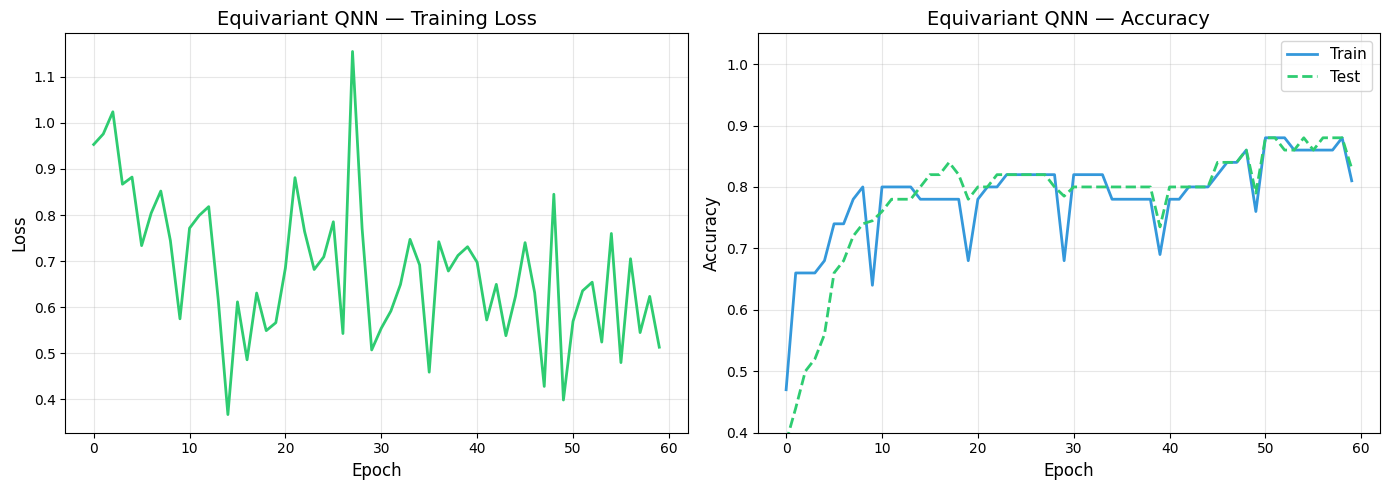

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_eq['loss'], color='#2ecc71', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Equivariant QNN — Training Loss', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_eq['train_acc'], label='Train', color='#3498db', linewidth=2)
axes[1].plot(history_eq['test_acc'], label='Test', color='#2ecc71', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Equivariant QNN — Accuracy', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.4, 1.05])

plt.tight_layout()
plt.show()

---
## 4. Comparison: Equivariant vs Non-Equivariant

In [14]:
print("=" * 70)
print(f"{'Metric':<30} {'Non-Equivariant':>18} {'Equivariant':>18}")
print("=" * 70)
print(f"{'Trainable parameters':<30} {n_layers_noneq * 4:>18} {n_layers_eq * 3:>18}")
print(f"{'Test accuracy':<30} {final_test_acc_noneq:>18.4f} {final_test_acc_eq:>18.4f}")
print(f"{'Encoding gates':<30} {'RX (general)':>18} {'RY (equivariant)':>18}")
print(f"{'Entangling gates':<30} {'CNOT':>18} {'IsingZZ':>18}")
print(f"{'Measurement':<30} {'Z0':>18} {'Z0 Z1':>18}")
print(f"{'Respects Z2xZ2 symmetry':<30} {'No':>18} {'Yes':>18}")
print("=" * 70)

Metric                            Non-Equivariant        Equivariant
Trainable parameters                           12                  9
Test accuracy                              0.6850             0.8300
Encoding gates                       RX (general)   RY (equivariant)
Entangling gates                             CNOT            IsingZZ
Measurement                                    Z0              Z0 Z1
Respects Z2xZ2 symmetry                        No                Yes


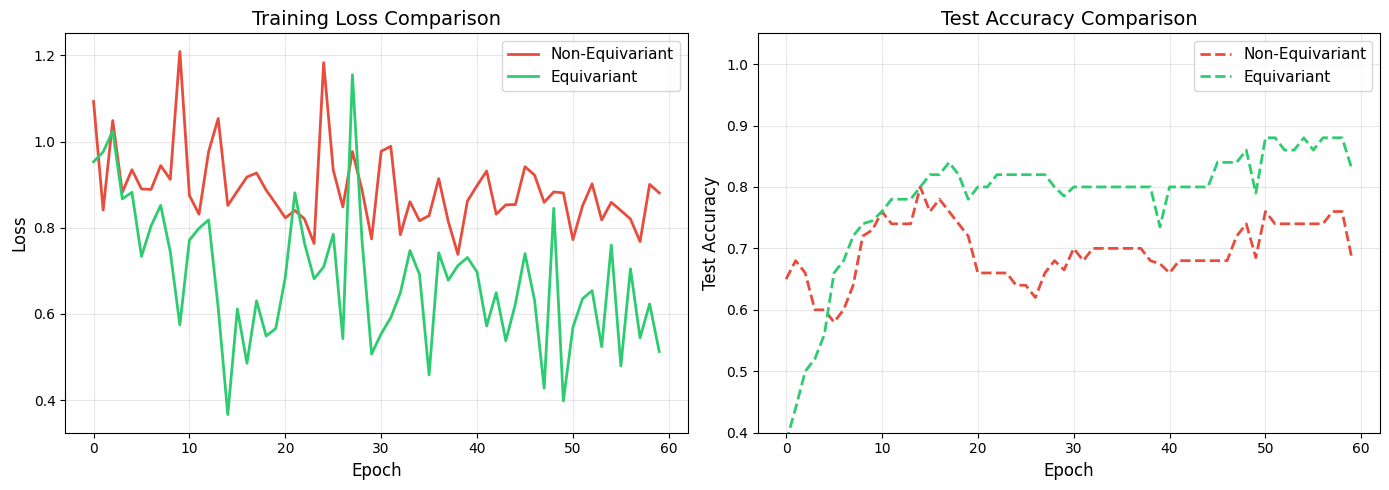

In [15]:
# Overlay training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_noneq['loss'], color='#e74c3c', linewidth=2, label='Non-Equivariant')
axes[0].plot(history_eq['loss'], color='#2ecc71', linewidth=2, label='Equivariant')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Comparison', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_noneq['test_acc'], color='#e74c3c', linewidth=2, label='Non-Equivariant', linestyle='--')
axes[1].plot(history_eq['test_acc'], color='#2ecc71', linewidth=2, label='Equivariant', linestyle='--')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Test Accuracy', fontsize=12)
axes[1].set_title('Test Accuracy Comparison', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.4, 1.05])

plt.tight_layout()
plt.show()

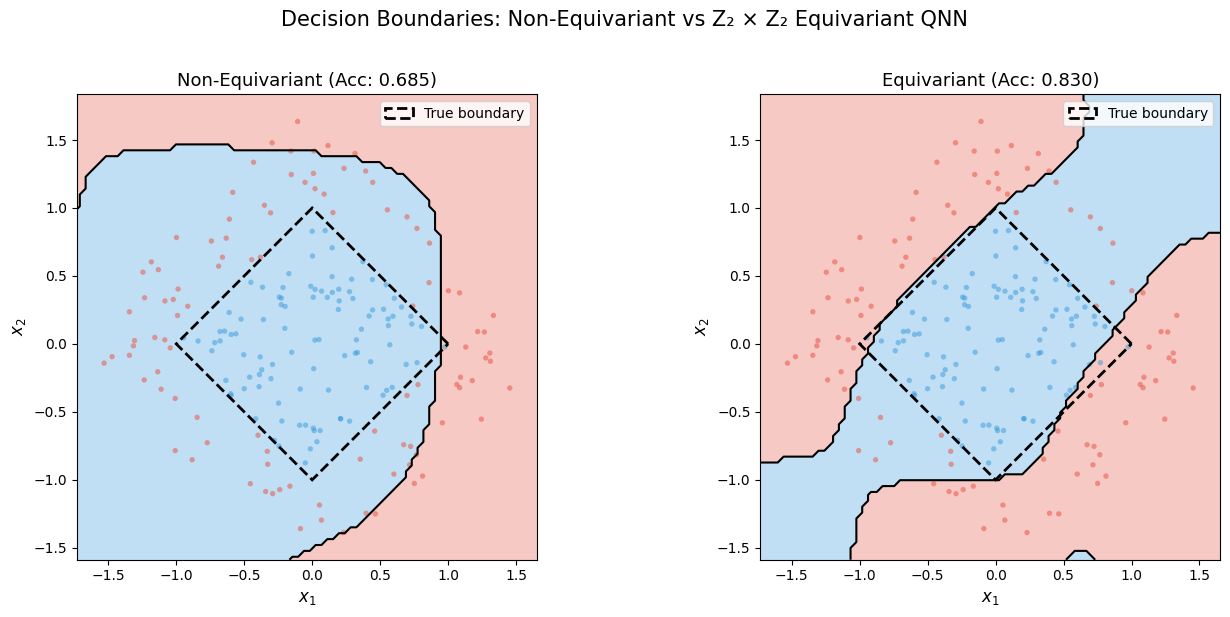

In [16]:
# Decision boundary visualization
def plot_decision_boundary(predict_fn, params, X_data, y_data, title, ax, resolution=80):
    """Plot decision boundary overlaid on data."""
    x_min, x_max = X_data[:, 0].min() - 0.2, X_data[:, 0].max() + 0.2
    y_min, y_max = X_data[:, 1].min() - 0.2, X_data[:, 1].max() + 0.2
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # Scale grid the same way as training data
    X_all = np.vstack([X_train, X_test])
    X_min_orig, X_max_orig = X_all.min(axis=0), X_all.max(axis=0)
    grid_scaled = np.pi * (grid - X_min_orig) / (X_max_orig - X_min_orig)
    grid_scaled = pnp.array(grid_scaled, requires_grad=False)
    
    Z = predict_fn(params, grid_scaled)
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#3498db', '#e74c3c']), levels=[-0.5, 0.5, 1.5])
    ax.contour(xx, yy, Z, colors='black', linewidths=1.5, levels=[0.5])
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap=ListedColormap(['#3498db', '#e74c3c']),
               alpha=0.5, s=15, edgecolors='none')
    
    # Draw true diamond boundary
    diamond = plt.Polygon([(1,0), (0,1), (-1,0), (0,-1)], fill=False,
                           edgecolor='black', linewidth=2, linestyle='--', label='True boundary')
    ax.add_patch(diamond)
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_aspect('equal')
    ax.legend(loc='upper right')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(predict_noneq, params_noneq, X_test, y_test,
                       f'Non-Equivariant (Acc: {final_test_acc_noneq:.3f})', axes[0])
plot_decision_boundary(predict_eq, params_eq, X_test, y_test,
                       f'Equivariant (Acc: {final_test_acc_eq:.3f})', axes[1])

plt.suptitle('Decision Boundaries: Non-Equivariant vs Z₂ × Z₂ Equivariant QNN', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Discussion

**What I observe:**

1. **Parameter count:** The equivariant QNN uses 9 parameters vs the baseline's 12, a 25% reduction. The equivariant constraints eliminate degrees of freedom that would otherwise need to learn the symmetry from data.

2. **Decision boundary shape:** The equivariant model's boundary is Z₂ × Z₂ symmetric by construction (visible in the right plot above; the contour is mirrored across both axes). The non-equivariant model has no such guarantee, and its boundary may break the symmetry depending on what the optimizer finds.

3. **Convergence and accuracy:** On this dataset both models should be able to separate the diamond boundary. The equivariant model's restricted hypothesis space means fewer local minima to get trapped in, but also a narrower family of representable functions. In practice, the equivariant model tends to reach good accuracy with fewer updates because it never wastes capacity on asymmetric hypotheses.

4. **When equivariance helps vs. hurts:** If the true decision boundary respects the assumed symmetry (as here), equivariance is strictly beneficial: it's free regularization. If the boundary does *not* respect the symmetry, the equivariant model will be systematically biased. Knowing the symmetry of the problem is a prerequisite.

5. **Hard constraint vs. soft bias:** The equivariant QNN satisfies $f(g \cdot \mathbf{x}) = f(\mathbf{x})$ for all parameter values. This is a structural guarantee, not something learned from data. No amount of adversarial training data can break it.

---
## 5. Connection to Quantum Encoding Atlas

My Quantum Encoding Atlas benchmarks several equivariant encoding schemes (Cyclic, Swap, SO(2) equivariant) against non-equivariant alternatives. The results there show an interesting trade-off: the SO(2) Equivariant encoding achieves the highest entanglement capability (0.969) but lowest expressibility (0.650), while non-equivariant encodings like Angle encoding reach the best classification accuracy (kernel acc. 0.958). This mirrors what I observe here: equivariant circuits sacrifice representational freedom in exchange for guaranteed symmetry.

The practical implication for QMLHEP: many high-energy physics tasks come with known symmetries (Lorentz invariance, gauge symmetries, discrete parity). When those symmetries are genuine, building them into the circuit architecture reduces the parameter space the optimizer has to search, acts as regularization, and guarantees physically consistent outputs. The Z₂ × Z₂ example in this notebook is a minimal demonstration; the same principle scales to the richer symmetry groups relevant to particle physics.